# ENN583 — Week 8 Practical: Is the route blocked?

In this practical, you will build a simple perception system for a mobile robot. Given one forward-facing camera image, the system must decide whether the robot's **immediate straight-ahead route** is:

- **blocked:** an obstacle intersects the route in front of the robot; or
- **free:** the route is clear, even if shelves, boxes, or other objects appear beside it.

This is a binary **image-classification** problem. The output describes the whole image; it does not locate an obstacle with a bounding box or segment individual pixels.

Training a large vision model from scratch would require far more data and computation than we have here. Instead, you will begin with **DINOv2-Small**, a self-supervised vision transformer, and reuse its frozen visual features. You will compare a linear prediction head with a small nonlinear head to see how much task-specific modelling is needed on top of the pretrained representation.

You will then repeat the idea with **ResNet-18**, a convolutional neural network pretrained with ImageNet class labels. First you will use ResNet as another frozen feature extractor. Finally, you will unfreeze its last residual stage and partially fine-tune the backbone. This progression lets you compare three common ways to adapt a pretrained model: linear probing, training a more expressive head, and fine-tuning part of the backbone.

By the end of the practical, you should be able to:

- load a pretrained vision backbone from Hugging Face;
- explain the difference between a backbone and a task-specific head;
- extract and cache frozen image features;
- train and compare linear and nonlinear prediction heads;
- compare features from a vision transformer and a convolutional ResNet;
- partially fine-tune the final stage of a pretrained ResNet;
- evaluate hazard recall and unnecessary stops; and
- explain how a decision threshold changes the robot's behaviour.


## 0. Setup

Run the notebook using the supplied `enn583` environment. Start by importing the libraries and selecting the available compute device.


In [1]:
# PyTorch provides tensors, neural-network layers, and data loaders.
# torchvision reads the folder-based image dataset.
# Transformers loads pretrained models and their image processors.
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor, AutoModel

# Fix the random seed so that classifier initialisation is repeatable.
SEED = 583
torch.manual_seed(SEED)
np.random.seed(SEED)

# Use a CUDA GPU when one is available; otherwise use the CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


### Download the warehouse dataset

The images are distributed separately from the code repository. Run the following cell once to download and unpack them. If the `warehouse_dataset` folder already exists, the download is skipped.


In [2]:
from urllib.request import urlretrieve
from zipfile import ZipFile

DATASET_URL = (
    "https://github.com/nikosuenderhauf/enn583/releases/download/"
    "2026-week-08-dataset-v1/warehouse_dataset_v1.zip"
)
DATA_DIR = Path("warehouse_dataset")
ZIP_PATH = Path("warehouse_dataset_v1.zip")

if DATA_DIR.exists():
    print("Dataset already exists:", DATA_DIR)
else:
    print("Downloading dataset...")
    urlretrieve(DATASET_URL, ZIP_PATH)

    print("Unpacking dataset...")
    with ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR)

    print("Dataset ready:", DATA_DIR)


Unpacking dataset...
Dataset ready: warehouse_dataset


## 1. Inspect the warehouse data

Our dataset contains synthetic forward-facing views of warehouse aisles. It is organised in the folder structure expected by `torchvision.datasets.ImageFolder`:

```text
warehouse_dataset/
├── train/
│   ├── blocked/
│   └── free/
├── val/
│   ├── blocked/
│   └── free/
└── test/
    ├── blocked/
    └── free/
```

The folder name supplies each image's label. The three splits have different roles:

- **training:** fit the classifier's weights;
- **validation:** compare settings and choose a decision threshold; and
- **test:** make one final evaluation after all choices are fixed.



In [3]:
# ImageFolder discovers class names from the folder names.

raw_datasets = {
    split: ImageFolder(DATA_DIR / split)
    for split in ("train", "val", "test")
}

class_to_idx = raw_datasets["train"].class_to_idx
assert class_to_idx == {"blocked": 0, "free": 1}
assert all(ds.class_to_idx == class_to_idx for ds in raw_datasets.values())

for split, dataset in raw_datasets.items():
    counts = np.bincount(dataset.targets, minlength=2)
    print(f"{split:5s}: blocked={counts[0]:4d}, free={counts[1]:4d}")


train: blocked=  35, free=  35
val  : blocked=  35, free=  35
test : blocked=  35, free=  35


### Look at labelled examples

Before fitting a model, inspect both the images and their labels. The code below displays up to four training examples from each class. 


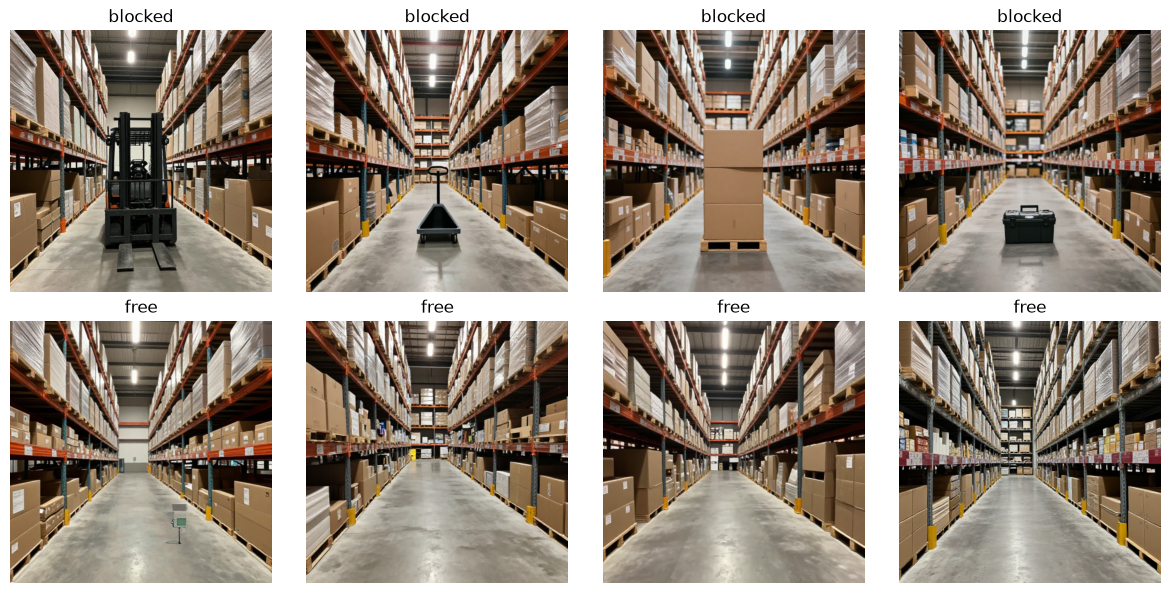

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for class_name, row in (("blocked", 0), ("free", 1)):
    class_index = class_to_idx[class_name]
    examples = [i for i, target in enumerate(raw_datasets["train"].targets)
                if target == class_index][:4]
    for axis, index in zip(axes[row], examples):
        image, target = raw_datasets["train"][index]
        axis.imshow(image)
        axis.set_title(raw_datasets["train"].classes[target])
        axis.axis("off")
plt.tight_layout()


## 2. Load a pretrained feature extractor

DINOv2 is a self-supervised vision model. It learned useful visual structure from a large image collection without being trained on our blocked/free labels. 
You can learn more about DINOv2 in the [paper](https://arxiv.org/abs/2304.07193) and the [Project Website](https://dinov2.metademolab.com/). The model is available on Hugging Face as `facebook/dinov2-small`. There is also a larger `dinov2-base` model, but it is slower and requires more memory. 

If you want to use the latest version in the DINO family, check out [DINOv3](https://ai.meta.com/blog/dinov3-self-supervised-vision-model/). It is also available on Hugging Face but you have to create an account first to accept the license and user agreement. Then you can use it for free in your research and education projects.

In this practical we will keep it simple and stick to DINOv2. It acts as a **backbone**: it converts an image into a numerical representation that another model can use.

We **freeze** the backbone by setting `requires_grad = False` for every parameter. Its weights will not change when we train a classificaion head later. We also call `eval()` so layers use evaluation behaviour. Only the small classification head introduced later will learn.

The model's preprocessing must match its pretraining. Cropping deserves particular attention in robotic vision because an object near the image boundary could determine whether the route is safe.


In [5]:
MODEL_ID = "facebook/dinov2-small"

# The first call downloads the processor and weights from Hugging Face.
# They are stored in the local Hugging Face cache for later runs.
# The processor applies the resize, crop, conversion, and normalisation
# expected by this particular pretrained model.

# The AutoImageProcessor and AutoModel classes are very convenient as they let you load any model from the Hugging Face Hub without having to know its architecture in advance. 
# The processor is responsible for preprocessing the images, while the model is the neural network itself.
processor = AutoImageProcessor.from_pretrained(MODEL_ID)
backbone = AutoModel.from_pretrained(MODEL_ID).to(DEVICE)

# Freeze the pretrained backbone: only our small classifier will be trained.
for parameter in backbone.parameters():
    parameter.requires_grad = False
backbone.eval()

# Inspect the processor, especially its resize and crop settings. What preprocessing is happening here?
print(processor)

# Count the number of parameters in the backbone. It will be around 22 million for dinov2-small.
print(f"Backbone parameters: {sum(p.numel() for p in backbone.parameters()):,}")


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

BitImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}

Backbone parameters: 22,056,576


### From image to feature vector

A vision transformer divides an image into patches and represents each patch with a vector -- this is what we call the tokens. DINOv2 also adds a special **CLS token**. 

After the transformer processes all tokens together, the output vector at token position 0 (the CLS token) provides a summary of the image. This is what we will use as the image's feature vector. The feature vector is a 384-dimensional floating-point tensor for DINOv2-Small.

Process one image first and inspect the tensor shapes before handling the complete dataset.


In [6]:
example_image, example_label = raw_datasets["train"][0]
example_inputs = processor(images=example_image, return_tensors="pt")
example_inputs = {name: value.to(DEVICE) for name, value in example_inputs.items()}

with torch.inference_mode():
    example_output = backbone(**example_inputs)

print("Model input:       ", example_inputs["pixel_values"].shape)
print("All token features:", example_output.last_hidden_state.shape)

# Dimension 0 indexes images in the batch. Dimension 1 indexes tokens.
# Token 0 is the CLS token; keeping ':' in dimension 0 keeps every image.
# DINOv2-Small produces a 384-value embedding vector for each image.
example_embedding = example_output.last_hidden_state[:, 0, :]

print("Image embedding:   ", example_embedding.shape)


Model input:        torch.Size([1, 3, 224, 224])
All token features: torch.Size([1, 257, 384])
Image embedding:    torch.Size([1, 384])


### Check your understanding

Use the printed shapes to answer these questions:

1. What do the three dimensions of `last_hidden_state` represent?
2. Why does `example_embedding` keep the batch dimension?
3. Where does the embedding size of 384 come from?

If you substitute a different backbone, do not assume it exposes a CLS token or uses 384 features. Inspect that model's documented outputs and the shapes it returns, and then change your code accordingly. For example, the ResNet-18 backbone used later in this practical does not have a CLS token and produces 512 features.


### Check your understanding

Use the printed shapes to answer these questions:

1.
1 = batch size. You passed in one image.
257 = number of tokens. DINOv2 cuts the 224×224 image into 14×14-pixel patches, giving 16 × 16 = 256 patch tokens. Adding the one CLS token makes 257.
384 = features per token. Each token is described by a vector of 384 numbers.
  
2. The indexing [:, 0, :] means "all images, token 0, all features." The : in the first position keeps the batch dimension, so the result is [1, 384] rather than [384]. This is deliberate, because PyTorch layers like the classification head you'll add later expect input shaped (batch, features). It also means the same code works for 1 image or 32.
   
3. 384 is the hidden size (also called the embedding dimension) of DINOv2-Small. It's an architecture choice made by the model's designers, and every token keeps this size through all the transformer layers. It doesn't depend on your image or dataset.


## 3. Extract and cache frozen features

We now pass every image through the frozen backbone and retain one feature vector per image. The labels and feature order must stay aligned so that we can train the head and later inspect incorrect predictions.


In [7]:
# Process only a few images at once to keep GPU memory use modest.
# Reduce this value if feature extraction runs out of GPU memory.
BATCH_SIZE = 8


# ImageFolder returns PIL images. This function processes a list of them
# together and returns pixel tensors plus their integer class labels.
def collate_images(batch):
    images, labels = zip(*batch)
    model_inputs = processor(images=list(images), return_tensors="pt")
    return model_inputs["pixel_values"], torch.tensor(labels)


loaders = {
    split: DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        # Keep feature order aligned with the original dataset.
        shuffle=False,
        num_workers=0,
        collate_fn=collate_images,
    )
    for split, dataset in raw_datasets.items()
}


def extract_features(loader):
    feature_batches = []
    label_batches = []
    
    backbone.eval()
    # Gradients are unnecessary because the backbone is frozen.
    with torch.inference_mode():
        for pixel_values, labels in loader:
            output = backbone(pixel_values=pixel_values.to(DEVICE)) 
            cls_features = output.last_hidden_state[:, 0, :]
            # Keep only the current image batch on the GPU. Cache features
            # on the CPU for the inexpensive head-training stage.
            feature_batches.append(cls_features.cpu())
            label_batches.append(labels)

    return torch.cat(feature_batches), torch.cat(label_batches)

features = {}
labels = {}
for split in ("train", "val", "test"):
    features[split], labels[split] = extract_features(loaders[split])
    print(split, features[split].shape, labels[split].shape)



train torch.Size([70, 384]) torch.Size([70])
val torch.Size([70, 384]) torch.Size([70])
test torch.Size([70, 384]) torch.Size([70])


### Why cache the features?

Feature extraction is the expensive part of this workflow. Because the backbone is frozen, the embedding for a particular preprocessed image is always the same. We can therefore compute every embedding once and train the small head repeatedly using the cached CPU tensors.

The cache stops being valid if you change the images, preprocessing, or backbone weights. In particular, cached embeddings cannot be used to fine-tune the backbone because they are no longer connected to the image-to-feature computation graph.


## 4. Train a linear classification head

The backbone produces one feature vector per image but does not know our two class names. We add a **classification head** consisting of one linear layer. It maps each 384-dimensional embedding to two output values called **logits**—one for `blocked` and one for `free`.

Logits are unrestricted scores, not probabilities. `CrossEntropyLoss` compares them with the correct integer class labels and internally performs the appropriate log-softmax calculation. Do not add a softmax layer to the head before this loss.

Only the head's weights appear in the optimiser, so the pretrained backbone remains unchanged. Each epoch below performs one update using all cached training features, followed by a validation-loss calculation with gradients disabled.


In [8]:
NUM_EPOCHS = 1000
LEARNING_RATE = 1e-2

embedding_size = features["train"].shape[1]

# Define a single linear layer with one output logit per class.
# Think about the input and output sizes of this layer: it has to map from the embedding size to the number of classes. Check the documentation for pytorch.nn.Linear to see how to specify the input and output sizes.
# head = ...
# TODO: Implement this solution.
head = nn.Linear(embedding_size, 2) # 2 = number of classes (blocked, unblocked)

loss_function = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(head.parameters(), lr=LEARNING_RATE)
print(head)


Linear(in_features=384, out_features=2, bias=True)


In [9]:
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    # since we do not have many images, and the features are small, we can process the entire training set in one go. This is not always possible with larger datasets or larger feature sizes, where you would need to use mini-batches.
    
    # train: update the head's parameters 
    head.train()
    optimiser.zero_grad()
    train_logits = head(features["train"])
    train_loss = loss_function(train_logits, labels["train"])
    train_loss.backward()
    optimiser.step()

    # evaluate: compute the validation loss without updating parameters
    head.eval()
    with torch.inference_mode():
        val_logits = head(features["val"])
        val_loss = loss_function(val_logits, labels["val"])

    # store both loss values for plotting later
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    # print every 5 epochs, and also the first epoch to see the initial loss
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print(f"epoch {epoch + 1:2d}: train={train_loss.item():.3f}, val={val_loss.item():.3f}")


epoch  1: train=1.097, val=5.935
epoch  5: train=3.353, val=4.229
epoch 10: train=2.193, val=2.140
epoch 15: train=1.124, val=1.417
epoch 20: train=0.594, val=0.880
epoch 25: train=0.186, val=0.437
epoch 30: train=0.137, val=0.264
epoch 35: train=0.183, val=0.224
epoch 40: train=0.159, val=0.199
epoch 45: train=0.099, val=0.214
epoch 50: train=0.061, val=0.130
epoch 55: train=0.055, val=0.127
epoch 60: train=0.054, val=0.135
epoch 65: train=0.048, val=0.113
epoch 70: train=0.041, val=0.131
epoch 75: train=0.037, val=0.115
epoch 80: train=0.035, val=0.115
epoch 85: train=0.033, val=0.124
epoch 90: train=0.030, val=0.114
epoch 95: train=0.029, val=0.118
epoch 100: train=0.027, val=0.118
epoch 105: train=0.026, val=0.114
epoch 110: train=0.025, val=0.117
epoch 115: train=0.024, val=0.115
epoch 120: train=0.023, val=0.113
epoch 125: train=0.022, val=0.114
epoch 130: train=0.021, val=0.113
epoch 135: train=0.020, val=0.112
epoch 140: train=0.019, val=0.112
epoch 145: train=0.018, val=0.111


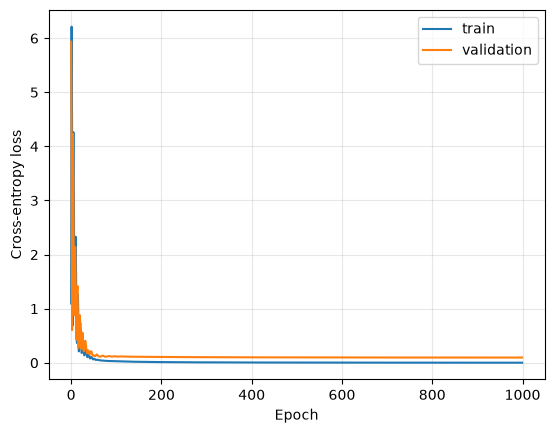

In [10]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Read the learning curves

Training loss measures how well the head fits examples used to update it. Validation loss measures how well it transfers to images that did not update its weights.

Consider the following questions:

1. Do both losses decrease at first?
2. Does validation loss eventually rise while training loss continues to fall? If so, what does that suggest?
3. Would you change the learning rate or number of epochs?

Use validation results—not test results—to make these choices. Repeatedly choosing settings based on the test split would turn it into another validation split and make the final performance estimate optimistic.


### Try a more expressive prediction head

The linear probe draws one linear decision boundary through the frozen DINO feature space. This is a useful baseline: it is fast, has few trainable parameters, and tells us how directly the pretrained representation separates our classes.

A small multilayer perceptron (MLP) can learn a nonlinear boundary. The example below adds one hidden layer, a ReLU activation, and dropout. It still uses cached DINO features, so the backbone remains frozen.

More capacity is not automatically better. With a small synthetic dataset, the MLP can overfit more easily than the linear head. Compare validation performance and the gap between training and validation loss rather than choosing the larger model simply because it is more complex.


In [36]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.net(x)

MLP(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)


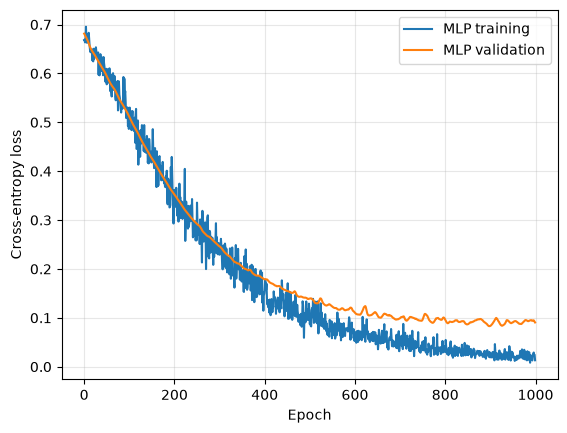

In [37]:
# Keep the original linear probe so that we can compare it with the MLP.
linear_head = head


# Build a two-layer nonlinear prediction head.
# Experiment with different hidden layer sizes, activation functions, and dropout rates. You can also try adding more layers, but be careful not to overfit the small training set.
# The best performance I got with a single hidden layer was an accuracy of 0.957 (see next cell). Maybe you can beat that?
# mlp_head = ...
# TODO: Implement this solution.
mlp_head = MLP(embedding_size, 32, 2)

MLP_EPOCHS = 1000
MLP_LEARNING_RATE = 1e-4        # feel free to experiment with this learning rate as well

mlp_loss_function = nn.CrossEntropyLoss()
mlp_optimiser = torch.optim.Adam(mlp_head.parameters(), lr=MLP_LEARNING_RATE)
mlp_train_losses = []
mlp_val_losses = []

# the training loop, very similar to the linear probe above, but now we are training a multi-layer perceptron (MLP) instead of a single linear layer
for epoch in range(MLP_EPOCHS):
    mlp_head.train()
    mlp_optimiser.zero_grad()
    train_logits = mlp_head(features["train"])
    train_loss = mlp_loss_function(train_logits, labels["train"])
    train_loss.backward()
    mlp_optimiser.step()

    # we are again evaluating the validation loss without updating parameters
    mlp_head.eval()
    with torch.inference_mode():
        val_logits = mlp_head(features["val"])
        val_loss = mlp_loss_function(val_logits, labels["val"])

    # save the loss values for plotting later
    mlp_train_losses.append(train_loss.item())
    mlp_val_losses.append(val_loss.item())

print(mlp_head)

plt.plot(mlp_train_losses, label="MLP training")
plt.plot(mlp_val_losses, label="MLP validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [38]:
# Compute the classification accuracy of a model on a given set of features and targets.
def classification_accuracy(model, input_features, targets):
    model.eval()
    with torch.inference_mode():
        predictions = model(input_features).argmax(dim=1)
    return (predictions == targets).float().mean().item()


# Compare the validation accuracy of the linear probe and the MLP probe.
linear_val_accuracy = classification_accuracy(
    linear_head, features["val"], labels["val"]
)
mlp_val_accuracy = classification_accuracy(
    mlp_head, features["val"], labels["val"]
)

print(f"Linear probe validation accuracy: {linear_val_accuracy:.3f}")
print(f"MLP probe validation accuracy:    {mlp_val_accuracy:.3f}")

Linear probe validation accuracy: 0.943
MLP probe validation accuracy:    0.943


## 5. Evaluate predictions and decisions

We now have two trained classifier heads. Each produces two logits for every image. The first logit corresponds to the `blocked` class and the second to `free`. 

But now the robot has to make a **decision**: should it stop or proceed? The robot's safety depends on this decision, so we need to evaluate the classifier's predictions in terms of the consequences of its decisions.

We treat **blocked as the positive class** because failing to detect a hazard is the safety-critical error. Applying softmax to the two logits produces a score between 0 and 1. This score is useful for ranking and thresholding, but it should not automatically be interpreted as a calibrated probability (we will come back to that topic in later weeks, but in a nutshell it means that a softmax score of 0.8 does not represent an 80% probability of the path being blocked).

The default decision rule predicts blocked when the blocked score is at least 0.5. We summarise its errors with a confusion matrix whose rows are true classes and columns are predicted classes.

Two rates are especially useful here:

- **hazard recall:** the fraction of truly blocked routes predicted blocked; and
- **unnecessary stop rate:** the fraction of truly free routes predicted blocked.

High hazard recall protects the robot from missed obstacles. A low unnecessary-stop rate prevents an overly cautious robot from stopping when it could proceed.


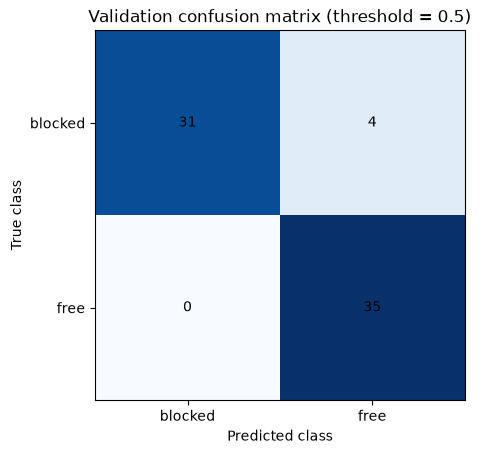

Hazard recall:          0.886
Unnecessary stop rate: 0.000


In [39]:
BLOCKED = class_to_idx["blocked"]
FREE = class_to_idx["free"]
threshold = 0.5


head.eval()
with torch.inference_mode():
    val_logits = head(features["val"])
    val_scores = torch.softmax(val_logits, dim=1)[:, BLOCKED]

val_predictions = torch.where(val_scores >= threshold, BLOCKED, FREE)
val_matrix = torch.zeros((2, 2), dtype=torch.int64)
for true_label, predicted_label in zip(labels["val"], val_predictions):
    val_matrix[true_label, predicted_label] += 1

fig, axis = plt.subplots()
axis.imshow(val_matrix, cmap="Blues")
axis.set_xticks([0, 1], labels=["blocked", "free"])
axis.set_yticks([0, 1], labels=["blocked", "free"])
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")
for row in range(2):
    for column in range(2):
        axis.text(column, row, val_matrix[row, column].item(),
                  ha="center", va="center")
plt.title("Validation confusion matrix (threshold = 0.5)")
plt.show()

hazard_recall = val_matrix[BLOCKED, BLOCKED] / val_matrix[BLOCKED].sum()
unnecessary_stop_rate = val_matrix[FREE, BLOCKED] / val_matrix[FREE].sum()
print(f"Hazard recall:          {hazard_recall:.3f}")
print(f"Unnecessary stop rate: {unnecessary_stop_rate:.3f}")


### Choose a threshold using validation data

The threshold converts a continuous model score into a discrete action. Lowering it makes the robot more willing to predict **blocked**. This will usually increase hazard recall, but it can also increase unnecessary stops.

The next cell evaluates several thresholds on the validation split. Complete the missing calculations, then examine the two curves. There may be no threshold that simultaneously gives perfect hazard recall and no unnecessary stops; the selected operating point must reflect the relative cost of the two errors.


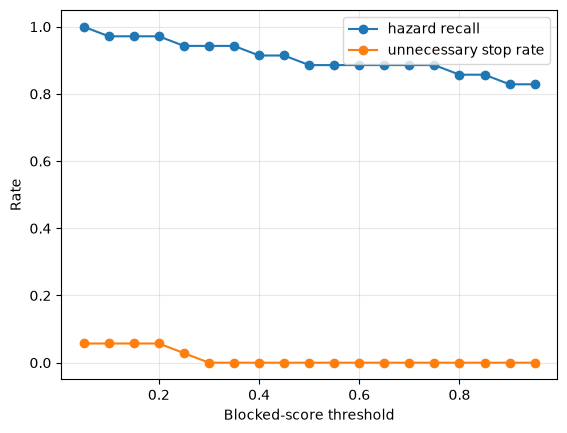

In [40]:
thresholds = np.linspace(0.05, 0.95, 19)
recalls = []
stop_rates = []
scores = val_scores

for threshold in thresholds:    
    predictions = torch.where(scores >= threshold, BLOCKED, FREE)
    true_blocked = labels["val"] == BLOCKED
    true_free = labels["val"] == FREE
    recalls.append((predictions[true_blocked] == BLOCKED).float().mean().item())
    stop_rates.append((predictions[true_free] == BLOCKED).float().mean().item())
    

plt.plot(thresholds, recalls, "o-", label="hazard recall")
plt.plot(thresholds, stop_rates, "o-", label="unnecessary stop rate")
plt.xlabel("Blocked-score threshold")
plt.ylabel("Rate")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [45]:
# Example policy: choose the largest threshold that still obtains at least
# 90% hazard recall on validation data. 
minimum_recall = 0.90


# find the threshold that achieves at least 90% hazard recall on validation data. 
# selected_threshold = ...
# TODO: Implement this solution.
selected_threshold = 0.30

print(f"Selected threshold: {selected_threshold:.2f}")

val_predictions = torch.where(
    val_scores >= selected_threshold, BLOCKED, FREE
)
selected_val_matrix = torch.zeros((2, 2), dtype=torch.int64)
for true_label, predicted_label in zip(labels["val"], val_predictions):
    selected_val_matrix[true_label, predicted_label] += 1
hazard_recall = (
    selected_val_matrix[BLOCKED, BLOCKED]
    / selected_val_matrix[BLOCKED].sum()
)
unnecessary_stop_rate = (
    selected_val_matrix[FREE, BLOCKED]
    / selected_val_matrix[FREE].sum()
)
print(f"Hazard recall:          {hazard_recall:.3f}")
print(f"Unnecessary stop rate: {unnecessary_stop_rate:.3f}")


Selected threshold: 0.30
Hazard recall:          0.943
Unnecessary stop rate: 0.000


### Inspect validation mistakes

A confusion matrix gives useful totals but does not explain why the model failed. The following cell displays up to eight incorrectly classified validation images.

Look for repeated failure modes such as unusual shadows, clutter near the route boundary, very small obstacles, ambiguous clearance, or backgrounds absent from the training split. Also consider whether the image label itself is defensible. This inspection can reveal problems with the data and task definition that no change to the optimiser will fix.


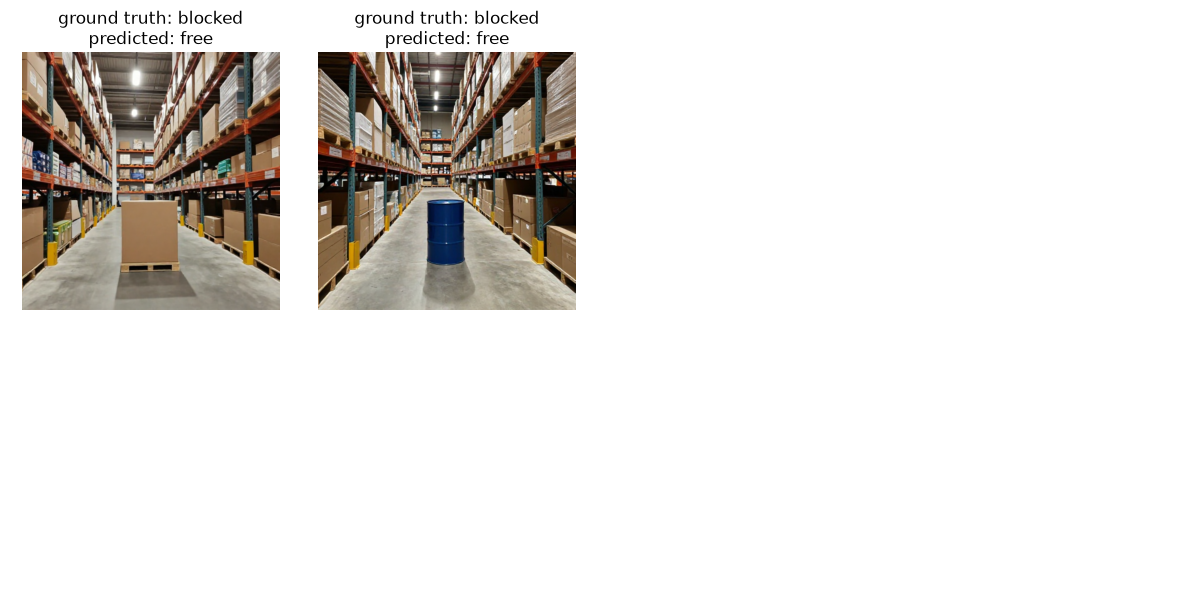

In [46]:
mistakes = torch.where(val_predictions != labels["val"])[0].tolist()[:8]

if mistakes:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for axis, index in zip(axes.flat, mistakes):
        image, target = raw_datasets["val"][index]
        predicted = val_predictions[index].item()
        axis.imshow(image)
        axis.set_title(
            f"ground truth: {raw_datasets['val'].classes[target]}\n"
            f"predicted: {raw_datasets['val'].classes[predicted]}"
        )
        axis.axis("off")
    for axis in axes.flat[len(mistakes):]:
        axis.axis("off")
    plt.tight_layout()
else:
    print("No validation mistakes at this threshold.")


### Make one final test evaluation

At this point the model settings and threshold should be fixed. Evaluate them once on the held-out test split to estimate performance on unseen synthetic warehouse scenes.

Do not return to earlier cells and tune the model using this result. If the test result motivates another round of development, make those changes using training and validation data and reserve a new independent test set for the next final evaluation.


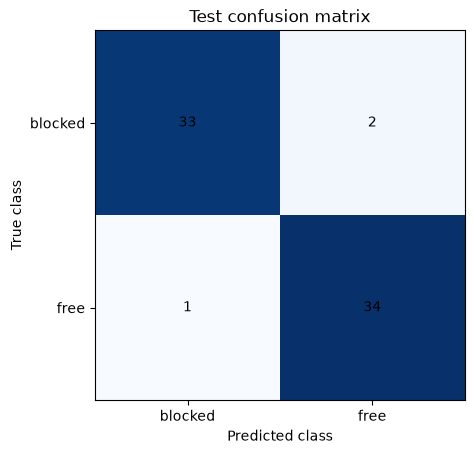

Hazard recall:          0.943
Unnecessary stop rate: 0.029


In [47]:
head.eval()
with torch.inference_mode():
    test_logits = head(features["test"])
    test_scores = torch.softmax(test_logits, dim=1)[:, BLOCKED]

test_predictions = torch.where(
    test_scores >= selected_threshold, BLOCKED, FREE
)
test_matrix = torch.zeros((2, 2), dtype=torch.int64)
for true_label, predicted_label in zip(labels["test"], test_predictions):
    test_matrix[true_label, predicted_label] += 1

fig, axis = plt.subplots()
axis.imshow(test_matrix, cmap="Blues")
axis.set_xticks([0, 1], labels=["blocked", "free"])
axis.set_yticks([0, 1], labels=["blocked", "free"])
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")
for row in range(2):
    for column in range(2):
        axis.text(column, row, test_matrix[row, column].item(),
                  ha="center", va="center")
plt.title("Test confusion matrix")
plt.show()

test_hazard_recall = test_matrix[BLOCKED, BLOCKED] / test_matrix[BLOCKED].sum()
test_stop_rate = test_matrix[FREE, BLOCKED] / test_matrix[FREE].sum()
print(f"Hazard recall:          {test_hazard_recall:.3f}")
print(f"Unnecessary stop rate: {test_stop_rate:.3f}")


### Interpret the result

Think about short responses to the following questions:

1. Which error is more costly here: a blocked route predicted free, or a free route predicted blocked?
2. How does your selected threshold reflect that difference in cost?
3. Does good performance on synthetic warehouse images establish that the classifier is ready for a real robot? Why or why not?
4. Why could overall accuracy hide an important safety problem?

Remember that a deployment environment may differ in camera height, field of view, lighting, textures, obstacle types, and image quality. This **distribution shift** can reduce performance even when held-out synthetic results look strong.


## 6. Save, reload, and predict one image

Saving only the linear layer is not enough to reconstruct the complete classifier. The checkpoint below records:

- the learned head weights;
- the embedding dimension and class-to-index mapping;
- the Hugging Face backbone identifier; and
- the selected blocked-score threshold.

The second cell creates a fresh linear layer, loads the saved weights, and runs one test image through the processor, frozen backbone, and reloaded head. This checks the complete inference path.

For a real experiment, also record the package versions, exact data version, training settings, and any preprocessing choices needed to reproduce the result.


In [48]:
CHECKPOINT_PATH = Path("week_8_route_classifier.pt")
checkpoint = {
    "head_state_dict": head.state_dict(),
    "embedding_size": embedding_size,
    "class_to_idx": class_to_idx,
    "model_id": MODEL_ID,
    "blocked_threshold": float(selected_threshold),
}
torch.save(checkpoint, CHECKPOINT_PATH)
print("Saved", CHECKPOINT_PATH)


Saved week_8_route_classifier.pt


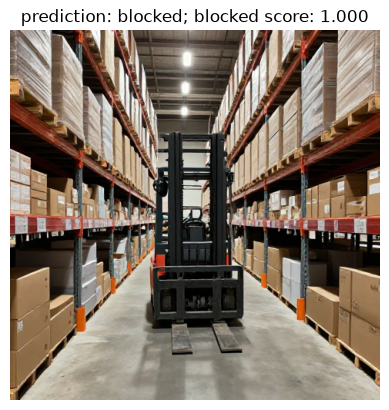

In [49]:
saved = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
reloaded_head = nn.Linear(saved["embedding_size"], len(saved["class_to_idx"]))
reloaded_head.load_state_dict(saved["head_state_dict"])
reloaded_head.eval()


def predict_image(image):
    inputs = processor(images=image, return_tensors="pt")
    with torch.inference_mode():
        output = backbone(pixel_values=inputs["pixel_values"].to(DEVICE))
        embedding = output.last_hidden_state[:, 0, :].cpu()
        score = torch.softmax(reloaded_head(embedding), dim=1)[0, BLOCKED].item()
    label = "blocked" if score >= saved["blocked_threshold"] else "free"
    return label, score


new_image, true_index = raw_datasets["test"][0]
prediction, score = predict_image(new_image)
plt.imshow(new_image)
plt.title(f"prediction: {prediction}; blocked score: {score:.3f}")
plt.axis("off")
plt.show()


## 7. Compare with ResNet-18

DINOv2 is a vision transformer trained with self-supervision. We will now repeat the main idea with **ResNet-18**, a smaller convolutional neural network pretrained for ImageNet classification.

This comparison changes both the architecture and the pretraining objective, so it is not a controlled experiment about architecture alone. It does, however, show that the same backbone-plus-head pattern applies to different model families.

We first use ResNet as a frozen feature extractor. Its pooled representation has 512 values rather than DINOv2-Small's 384, and it is accessed through `pooler_output` rather than a CLS token.


In [50]:
RESNET_ID = "microsoft/resnet-18"

resnet_processor = AutoImageProcessor.from_pretrained(RESNET_ID)
resnet = AutoModel.from_pretrained(RESNET_ID).to(DEVICE)

# Freeze ResNet for the initial linear-probe comparison.
for parameter in resnet.parameters():
    parameter.requires_grad = False
resnet.eval()

print(f"ResNet parameters: {sum(p.numel() for p in resnet.parameters()):,}")


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.5k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/120 [00:00<?, ?it/s]

[transformers] ResNetModel LOAD REPORT from: microsoft/resnet-18
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.1.bias   | UNEXPECTED |  | 
classifier.1.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ResNet parameters: 11,176,512


### Extract frozen ResNet features

ResNet has its own preprocessing and representation, so we extract a fresh set of frozen features rather than reusing the DINOv2 embeddings.


In [51]:
# ResNet has its own processor and loaders. Keep this batch size separate
# so it can be adjusted without changing the DINOv2 experiment.
RESNET_BATCH_SIZE = 8


def collate_resnet_images(batch):
    images, targets = zip(*batch)
    inputs = resnet_processor(images=list(images), return_tensors="pt")
    return inputs["pixel_values"], torch.tensor(targets)


resnet_loaders = {
    split: DataLoader(
        dataset,
        batch_size=RESNET_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_resnet_images,
    )
    for split, dataset in raw_datasets.items()
}


def extract_resnet_features(loader):
    feature_batches = []
    target_batches = []

    resnet.eval()
    with torch.inference_mode():
        for pixel_values, targets in loader:
            output = resnet(pixel_values=pixel_values.to(DEVICE))
            # pooler_output has shape (batch, 512, 1, 1). Remove the two
            # singleton spatial dimensions to obtain (batch, 512).
            pooled_features = output.pooler_output.flatten(1)
            feature_batches.append(pooled_features.cpu())
            target_batches.append(targets)

    return torch.cat(feature_batches), torch.cat(target_batches)


resnet_features = {}
resnet_labels = {}
for split in ("train", "val", "test"):
    resnet_features[split], resnet_labels[split] = extract_resnet_features(
        resnet_loaders[split]
    )
    print(split, resnet_features[split].shape)


train torch.Size([70, 512])
val torch.Size([70, 512])
test torch.Size([70, 512])


### Train a linear probe on ResNet

The prediction head still has two output logits, but its input size is read from the cached ResNet features. We train it directly on the cached features using the same basic steps as the DINO probes.

Compare validation accuracy with the DINO probes, but remember that accuracy does not describe which class is being missed. A complete comparison would also repeat the threshold and confusion-matrix analysis for this model.


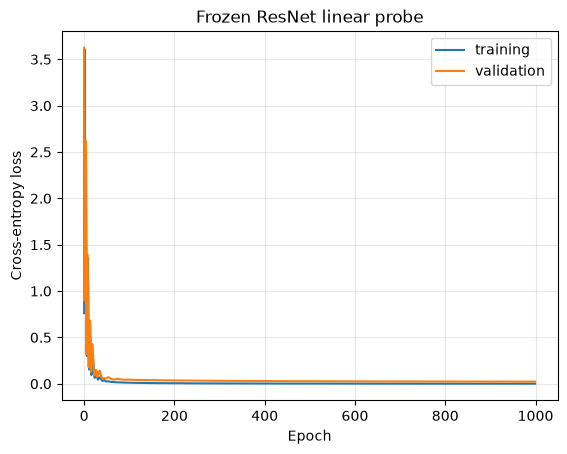

Frozen ResNet validation accuracy: 0.986
Dinov2 MLP-head validation accuracy: 0.943
Dinov2 linear-head validation accuracy: 0.943


In [58]:
resnet_embedding_size = resnet_features["train"].shape[1]

# resnet_head = ...
# TODO: Implement this solution.
resnet_head = nn.Linear(resnet_embedding_size, 2)

RESNET_PROBE_EPOCHS = 1000
RESNET_PROBE_LEARNING_RATE = 1e-2

resnet_loss_function = nn.CrossEntropyLoss()
resnet_optimiser = torch.optim.Adam(
    resnet_head.parameters(), lr=RESNET_PROBE_LEARNING_RATE
)
resnet_train_losses = []
resnet_val_losses = []

# Implement the training loop for the ResNet probe. It is very similar to the DINOv2 probe above, but now we are training a linear layer on top of ResNet features instead of DINOv2 features.

for epoch in range(RESNET_PROBE_EPOCHS):
    # TODO: Implement this solution.
    resnet_head.train()
    resnet_optimiser.zero_grad()
    train_logits = resnet_head(resnet_features["train"])
    train_loss = resnet_loss_function(train_logits, resnet_labels["train"])
    train_loss.backward()
    resnet_optimiser.step()

    resnet_head.eval()
    with torch.inference_mode():
        val_logits = resnet_head(resnet_features["val"])
        val_loss = resnet_loss_function(
            val_logits, resnet_labels["val"]
        )

    resnet_train_losses.append(train_loss.item())
    resnet_val_losses.append(val_loss.item())


plt.plot(resnet_train_losses, label="training")
plt.plot(resnet_val_losses, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Frozen ResNet linear probe")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


resnet_val_accuracy = classification_accuracy(
    resnet_head, resnet_features["val"], resnet_labels["val"]
)
print(f"Frozen ResNet validation accuracy: {resnet_val_accuracy:.3f}")
print(f"Dinov2 MLP-head validation accuracy: {mlp_val_accuracy:.3f}")
print(f"Dinov2 linear-head validation accuracy: {linear_val_accuracy:.3f}")


### Diagnose the frozen ResNet probe

Accuracy alone does not tell us which errors the ResNet probe makes. Before changing the backbone, evaluate the frozen probe using the same safety-oriented diagnostics used for DINOv2.

The confusion matrix uses true classes as rows and predicted classes as columns. We again report hazard recall and unnecessary-stop rate at a blocked-score threshold of 0.5. Keeping the threshold fixed makes this an initial comparison; a fair deployment comparison would select a separate threshold for each model using validation data.


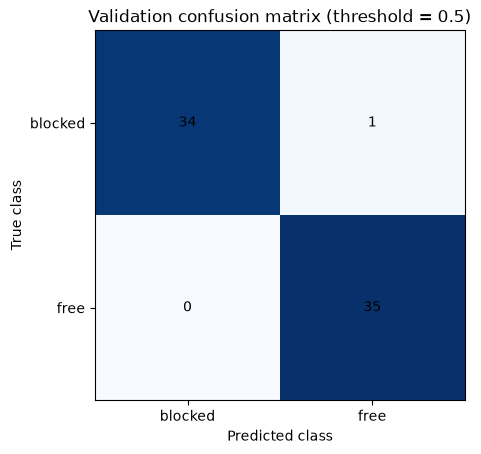

Hazard recall:          0.971
Unnecessary stop rate: 0.000


In [59]:
BLOCKED = class_to_idx["blocked"]
FREE = class_to_idx["free"]
threshold = 0.5


resnet_head.eval()
with torch.inference_mode():
    val_logits = resnet_head(resnet_features["val"])
    val_scores = torch.softmax(val_logits, dim=1)[:, BLOCKED]

val_predictions = torch.where(val_scores >= threshold, BLOCKED, FREE)
val_matrix = torch.zeros((2, 2), dtype=torch.int64)
for true_label, predicted_label in zip(resnet_labels["val"], val_predictions):
    val_matrix[true_label, predicted_label] += 1

fig, axis = plt.subplots()
axis.imshow(val_matrix, cmap="Blues")
axis.set_xticks([0, 1], labels=["blocked", "free"])
axis.set_yticks([0, 1], labels=["blocked", "free"])
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")
for row in range(2):
    for column in range(2):
        axis.text(column, row, val_matrix[row, column].item(),
                  ha="center", va="center")
plt.title("Validation confusion matrix (threshold = 0.5)")
plt.show()

hazard_recall = val_matrix[BLOCKED, BLOCKED] / val_matrix[BLOCKED].sum()
unnecessary_stop_rate = val_matrix[FREE, BLOCKED] / val_matrix[FREE].sum()
print(f"Hazard recall:          {hazard_recall:.3f}")
print(f"Unnecessary stop rate: {unnecessary_stop_rate:.3f}")


### Inspect ResNet mistakes

Look at the images behind the aggregate result. If there are no validation mistakes, inspect the lowest-scoring blocked images and highest-scoring free images instead: these are the cases closest to changing the model's decision.


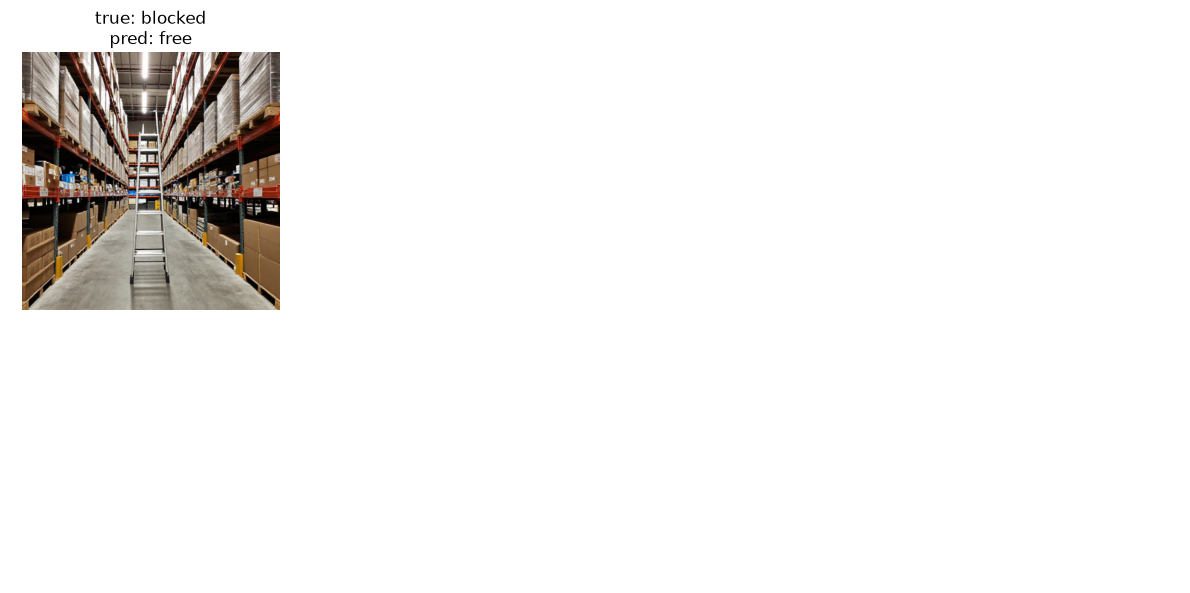

In [60]:
resnet_mistakes = torch.where(
    val_predictions != resnet_labels["val"]
)[0].tolist()[:8]

if resnet_mistakes:
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for axis, index in zip(axes.flat, resnet_mistakes):
        image, target = raw_datasets["val"][index]
        predicted = val_predictions[index].item()
        axis.imshow(image)
        axis.set_title(
            f"true: {raw_datasets['val'].classes[target]}\n"
            f"pred: {raw_datasets['val'].classes[predicted]}"
        )
        axis.axis("off")
    for axis in axes.flat[len(resnet_mistakes):]:
        axis.axis("off")
    plt.tight_layout()
else:
    print("No ResNet validation mistakes at this threshold.")


## 8. Fine-tune the final ResNet stage

A linear probe asks whether the existing representation already separates blocked and free images. **Fine-tuning** also changes some backbone weights so the representation can adapt to our task.

We will keep most of ResNet frozen and unfreeze only its final residual stage. This is called **partial fine-tuning**. It uses less memory and is less likely to destroy useful pretrained features than updating the complete network on a small dataset.

Fine-tuning must start from image batches rather than cached features. We use two learning rates:

- a small learning rate for the pretrained residual stage; and
- a larger learning rate for the task-specific head.

The head starts from the frozen-probe weights instead of being randomly reinitialised.


In [61]:
FINE_TUNE_EPOCHS = 8
BACKBONE_LEARNING_RATE = 1e-5
HEAD_LEARNING_RATE = 1e-3

# Unfreeze only the final residual stage.
for parameter in resnet.parameters():
    parameter.requires_grad = False

final_residual_stage = resnet.encoder.stages[-1]
for parameter in final_residual_stage.parameters():
    parameter.requires_grad = True

resnet_head = resnet_head.to(DEVICE)
fine_tune_optimiser = torch.optim.Adam(
    [
        {"params": final_residual_stage.parameters(), "lr": BACKBONE_LEARNING_RATE},
        {"params": resnet_head.parameters(), "lr": HEAD_LEARNING_RATE},
    ]
)

trainable_backbone_parameters = sum(
    parameter.numel() for parameter in resnet.parameters()
    if parameter.requires_grad
)
print(f"Trainable backbone parameters: {trainable_backbone_parameters:,}")


Trainable backbone parameters: 8,393,728


In [62]:
fine_tune_train_losses = []
fine_tune_val_losses = []
loss_function = nn.CrossEntropyLoss()

for epoch in range(FINE_TUNE_EPOCHS):
    # Keep frozen stages in evaluation mode. Only the final stage and head train.
    resnet.eval()
    final_residual_stage.train()
    resnet_head.train()
    running_loss = 0.0

    for pixel_values, targets in resnet_loaders["train"]:
        pixel_values = pixel_values.to(DEVICE)
        targets = targets.to(DEVICE)

        fine_tune_optimiser.zero_grad()
        output = resnet(pixel_values=pixel_values)
        image_features = output.pooler_output.flatten(1)
        logits = resnet_head(image_features)
        loss = loss_function(logits, targets)
        loss.backward()
        fine_tune_optimiser.step()

        running_loss += loss.item() * len(targets)

    fine_tune_train_losses.append(
        running_loss / len(raw_datasets["train"])
    )

    resnet.eval()
    resnet_head.eval()
    running_val_loss = 0.0
    with torch.inference_mode():
        for pixel_values, targets in resnet_loaders["val"]:
            pixel_values = pixel_values.to(DEVICE)
            targets = targets.to(DEVICE)
            output = resnet(pixel_values=pixel_values)
            image_features = output.pooler_output.flatten(1)
            logits = resnet_head(image_features)
            loss = loss_function(logits, targets)
            running_val_loss += loss.item() * len(targets)

    fine_tune_val_losses.append(
        running_val_loss / len(raw_datasets["val"])
    )
    print(
        f"epoch {epoch + 1:2d}: "
        f"train={fine_tune_train_losses[-1]:.3f}, "
        f"val={fine_tune_val_losses[-1]:.3f}"
    )


epoch  1: train=4.193, val=0.174
epoch  2: train=1.536, val=0.012
epoch  3: train=0.686, val=0.026
epoch  4: train=0.861, val=0.013
epoch  5: train=0.619, val=0.009
epoch  6: train=0.362, val=0.013
epoch  7: train=0.304, val=0.017
epoch  8: train=0.314, val=0.014


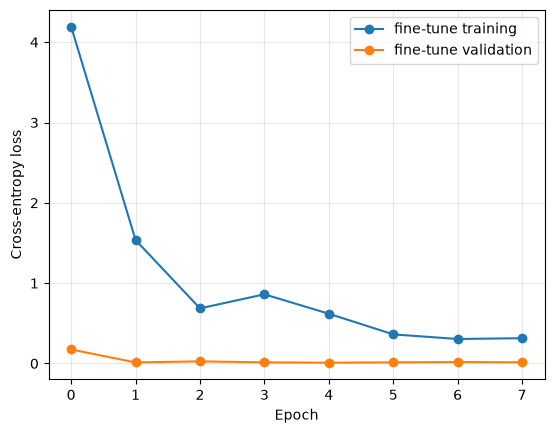

Fine-tuned ResNet validation accuracy: 1.000


In [63]:
plt.plot(fine_tune_train_losses, "o-", label="fine-tune training")
plt.plot(fine_tune_val_losses, "o-", label="fine-tune validation")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


def resnet_image_accuracy(loader):
    correct = 0
    total = 0
    resnet.eval()
    resnet_head.eval()
    with torch.inference_mode():
        for pixel_values, targets in loader:
            targets = targets.to(DEVICE)
            output = resnet(pixel_values=pixel_values.to(DEVICE))
            features_batch = output.pooler_output.flatten(1)
            predictions = resnet_head(features_batch).argmax(dim=1)
            correct += (predictions == targets).sum().item()
            total += len(targets)
    return correct / total


fine_tuned_val_accuracy = resnet_image_accuracy(resnet_loaders["val"])
print(f"Fine-tuned ResNet validation accuracy: {fine_tuned_val_accuracy:.3f}")


### Compare the three levels of adaptation

You have now tried three increasingly flexible approaches:

1. **linear probing:** train one linear layer on frozen features;
2. **nonlinear probing:** train a small MLP on frozen features; and
3. **partial fine-tuning:** update the prediction head and part of the backbone.

Greater flexibility costs more computation and can increase overfitting. Record the validation metrics, training time, and trainable parameter count for each approach. Which is justified by the evidence from this dataset?

For a safety-oriented comparison, adapt the earlier blocked-score and confusion-matrix functions to the fine-tuned ResNet outputs. Select its threshold using validation data before evaluating it on held-out test data.


## Further experiments

If time permits, try changing one factor at a time:

- change the MLP hidden-layer width or add dropout or more layers;
- fine-tune more or fewer ResNet stages;
- fine-tune the final DINOv2 transformer block using a small learning rate; or
- test on images with different lighting, camera height, or obstacle types.

Keep a frozen linear probe as the baseline. Use the same data splits and safety metrics so that each comparison remains meaningful.


## Take-away

A pretrained backbone converts images into reusable visual representations. A small task-specific head converts those representations into blocked/free logits, and a decision threshold converts the blocked score into a robot action.

Freezing and caching make training inexpensive, but model weights are only one part of the system. The label definition, dataset splits, preprocessing, threshold, and deployment environment all affect its behaviour. For a safety-related task, inspect individual mistakes and report hazard recall and unnecessary stops rather than relying on accuracy alone.
